# 勇者傳說 — OWC Back View V3 (2 failed NPCs only)

## Why V2 failed for npc_shop and npc_save
1. **Too-generic prompts**: "plump merchant shopkeeper" and "holy priest cleric" → SDXL associates with front-facing portraits
2. **Insufficient back-view anatomy cues**: Need explicit hair/clothing rear details
3. **No composition forcing**: Model defaults to character-facing-viewer for recognizable NPC types

## V3 Fixes
1. **Explicit rear anatomy**: "back of shoulders visible, nape of neck, shoulder blades"
2. **Clothing rear details**: "apron strings tied in bow at back", "robes draping down from behind"
3. **Stronger negative**: Add "chest, face, nose, mouth, breast, belly, navel"
4. **3 prompts × 5 candidates** = 15 options per NPC
5. **Guidance 10.0**, steps 35

## Items (2): char_npc_shop_back, char_npc_save_back

In [1]:
# Cell 0: Setup + GPU guard
import os
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, time, torch
import numpy as np

assert torch.cuda.is_available(), 'GPU required! Runtime > Change runtime type > T4 GPU'
DEVICE = 'cuda'
DTYPE = torch.float16
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Output: {OUTPUT_BASE}')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 34.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 

In [2]:
# Cell 1: Utilities — bg removal, postprocess
from PIL import Image
from scipy import ndimage

_rmbg_model = None
_rembg_session = None

def remove_background(img):
    """RMBG-2.0 primary, rembg u2net fallback."""
    global _rmbg_model, _rembg_session
    try:
        if _rmbg_model is None:
            from transformers import pipeline
            _rmbg_model = pipeline('image-segmentation',
                                   model='briaai/RMBG-2.0',
                                   trust_remote_code=True,
                                   device=0)
        result = _rmbg_model(img)
        mask = result[0]['mask'] if isinstance(result, list) else result['mask']
        img = img.convert('RGBA')
        img.putalpha(mask.convert('L'))
        return img
    except Exception as e:
        print(f'[warn] RMBG-2.0 failed: {e}, trying rembg...')
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(img, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return img


def postprocess_character(img, target_w=64, target_h=96):
    """Remove bg, crop to content, resize to target, bottom-center align."""
    img = remove_background(img.convert('RGBA'))
    arr = np.array(img)
    alpha = arr[:, :, 3]
    rows_any = np.any(alpha > 10, axis=1)
    cols_any = np.any(alpha > 10, axis=0)
    if not rows_any.any():
        return img.resize((target_w, target_h), Image.NEAREST)
    rmin, rmax = np.where(rows_any)[0][[0, -1]]
    cmin, cmax = np.where(cols_any)[0][[0, -1]]
    cropped = img.crop((cmin, rmin, cmax + 1, rmax + 1))
    cw, ch = cropped.size
    scale = min(target_w / cw, target_h / ch)
    new_w = max(1, int(cw * scale))
    new_h = max(1, int(ch * scale))
    resized = cropped.resize((new_w, new_h), Image.NEAREST)
    canvas = Image.new('RGBA', (target_w, target_h), (0, 0, 0, 0))
    x = (target_w - new_w) // 2
    y = target_h - new_h  # bottom-align
    canvas.paste(resized, (x, y))
    return canvas


def is_back_view(img, threshold=0.30):
    """Heuristic: a back view should have less detail in the upper-center (no face).
    Compare variance in upper-center vs lower region."""
    arr = np.array(img.convert('RGBA'))
    alpha = arr[:, :, 3]
    h, w = arr.shape[:2]
    # Upper center region (where face would be if front-facing)
    uc = arr[int(h*0.05):int(h*0.35), int(w*0.25):int(w*0.75)]
    uc_alpha = uc[:, :, 3]
    if uc_alpha.sum() == 0:
        return True  # no content in face area = likely back
    uc_rgb = uc[:, :, :3].astype(float)
    # Check color variance — front faces have eyes/mouth = high color variance
    # Back of head = more uniform (hair)
    uc_var = np.mean([np.var(uc_rgb[uc_alpha > 10, c]) for c in range(3)])
    return uc_var < 2500  # back views tend to have lower variance (uniform hair)


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('Utilities loaded.')

Utilities loaded.


In [3]:
# Cell 2: Prompts — 3 variants per NPC, stronger back-view enforcement
#
# V2 failure analysis:
#   - "plump merchant shopkeeper" → SDXL defaults to front portrait (iconic pose)
#   - "holy priest cleric" → same, SDXL loves front-facing religious figures
#
# V3 fixes:
#   - Explicit rear anatomy: "back of shoulders, nape of neck, shoulder blades"
#   - Clothing rear details: "apron strings tied in bow at back"
#   - De-emphasize character identity, emphasize pose/viewpoint
#   - 3 prompt variants with different keyword strategies

# V3: Much stronger negative — block ALL front-facing body cues
NEGATIVE = (
    'front view, face, eyes, nose, mouth, looking at viewer, facing camera, '
    'facing forward, portrait, frontal, chest, breast, belly, navel, '
    'smiling, expression, gaze, staring, '
    'blurry, text, watermark, signature, multiple characters, duplicate, '
    'sprite sheet, multiple views, turnaround, '
    'realistic photo, complex background, border, frame'
)

ENTRIES = [
    # ── char_npc_shop (3 prompt variants) ──
    {
        'name': 'char_npc_shop',
        'variants': [
            # V1: Focus on rear clothing details
            ('pixel art, single chibi character viewed from directly behind, '
             'back of head visible, bald head with fringe, nape of neck, '
             'brown leather apron strings tied in bow at the back, brown tunic, '
             'broad shoulders seen from behind, '
             'standing idle facing away, solid dark background'),
            # V2: De-emphasize identity, emphasize pose
            ('pixel art RPG sprite, rear view of short stocky person, '
             'completely turned away from camera showing only their back, '
             'back of bald round head, leather apron wrapping around body, '
             'brown work clothes, thick arms at sides, '
             'facing away from viewer, solid dark background'),
            # V3: Compositional framing
            ('16-bit JRPG pixel art, over-the-shoulder viewpoint from behind, '
             'chibi merchant NPC with back turned to camera, '
             'visible shoulder blades under brown apron, round bald head from behind, '
             'no face visible, only back of head and body, '
             'standing pose, solid dark background'),
        ],
    },
    # ── char_npc_save (3 prompt variants) ──
    {
        'name': 'char_npc_save',
        'variants': [
            # V1: Focus on rear clothing and hair
            ('pixel art, single chibi character viewed from directly behind, '
             'back of head visible, long flowing white hair cascading down back, '
             'ornate white and gold priestly robes seen from behind, flowing fabric, '
             'golden cross emblem on the back of robe, '
             'standing idle facing away, solid dark background'),
            # V2: De-emphasize identity
            ('pixel art RPG sprite, rear view of priestess figure, '
             'completely turned away from camera showing only their back, '
             'long silver white hair flowing down, white ceremonial robes draping, '
             'gold trim visible from behind, small frame, '
             'facing away from viewer, solid dark background'),
            # V3: Compositional framing
            ('16-bit JRPG pixel art, over-the-shoulder viewpoint from behind, '
             'chibi holy cleric NPC with back turned to camera, '
             'elaborate white vestments with gold accents seen from rear, '
             'long pale hair visible from behind, ornate headdress back, '
             'no face visible, only back of head and robes, '
             'standing pose, solid dark background'),
        ],
    },
]

print(f'V3 entries: {len(ENTRIES)} NPCs, {sum(len(e["variants"]) for e in ENTRIES)} prompt variants total')

V3 entries: 2 NPCs, 6 prompt variants total


In [4]:
# Cell 3: Load SDXL txt2img pipeline + pixel-art-xl LoRA
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
sdxl_cache = MODELS_DIR / 'sdxl-base-fp16'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading from: {model_path}')
t0 = time.time()

kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if 'stabilityai' in model_path:
    kwargs['variant'] = 'fp16'

pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs).to(DEVICE)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

try:
    pipe.load_lora_weights('nerijs/pixel-art-xl', adapter_name='pixel_xl')
    pipe.fuse_lora(lora_scale=0.7)
    pipe.unload_lora_weights()
    print('[pipeline] pixel-art-xl LoRA fused (scale=0.7)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe.enable_attention_slicing()

# Cache if first download
if 'stabilityai' in model_path and ON_COLAB:
    try:
        pipe.save_pretrained(str(sdxl_cache))
    except Exception:
        pass

print(f'[pipeline] Loaded in {time.time()-t0:.1f}s')

# Quick validation
print('[validation] Test image...')
_t = pipe(prompt='red square', negative_prompt='', width=64, height=64,
          num_inference_steps=5, guidance_scale=1.0,
          generator=torch.Generator(device=DEVICE).manual_seed(0))
del _t; free_vram()
print('[validation] Pipeline OK')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[pipeline] Loading from: /content/drive/MyDrive/ai-rpg-game/models/sdxl-base-fp16


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA fused (scale=0.7)
[pipeline] Loaded in 280.2s
[validation] Test image...


  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


[validation] Pipeline OK


In [5]:
# Cell 4: Generate all candidates — 3 variants × 5 seeds = 15 per NPC
import matplotlib.pyplot as plt

TARGET_W, TARGET_H = 64, 96
GUIDANCE = 10.0    # higher than V2's 9.5 for stricter prompt following
STEPS = 35         # more than V2's 28 for better detail
NUM_SEEDS = 5

out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

# Load front images for visual comparison
FRONT_DIR = OUTPUT_BASE / 'overworld_characters'
front_images = {}
for entry in ENTRIES:
    fp = FRONT_DIR / f'{entry["name"]}.png'
    if fp.exists():
        front_images[entry['name']] = Image.open(fp).convert('RGBA')
        print(f'Front loaded: {entry["name"]}')

all_candidates = {}  # name -> list of (variant_idx, seed, processed_img, raw_img)

for entry in ENTRIES:
    name = entry['name']
    candidates = []
    print(f'\n{"="*60}')
    print(f'Generating: {name}_back ({len(entry["variants"])} variants × {NUM_SEEDS} seeds)')
    print(f'{"="*60}')

    for vi, variant_prompt in enumerate(entry['variants']):
        print(f'\n  Variant {vi+1}/{len(entry["variants"])}:')
        print(f'    {variant_prompt[:80]}...')

        for si in range(NUM_SEEDS):
            seed = 600 + vi * 100 + si * 13  # unique seeds per variant
            generator = torch.Generator(device=DEVICE).manual_seed(seed)

            result = pipe(
                prompt=variant_prompt,
                negative_prompt=NEGATIVE,
                width=512, height=768,  # portrait orientation for character
                num_inference_steps=STEPS,
                guidance_scale=GUIDANCE,
                generator=generator,
            )
            raw = result.images[0]
            processed = postprocess_character(raw, TARGET_W, TARGET_H)

            # Check if it's actually a back view
            back_check = is_back_view(processed)
            status = 'BACK' if back_check else 'FRONT?'

            candidates.append((vi, seed, processed, raw, back_check))
            print(f'    seed={seed} [{status}]', end=' ')

        free_vram()

    all_candidates[name] = candidates
    print(f'\n  Total candidates for {name}: {len(candidates)}')

print(f'\n\nGeneration complete! {sum(len(c) for c in all_candidates.values())} total candidates')

Front loaded: char_npc_shop
Front loaded: char_npc_save

Generating: char_npc_shop_back (3 variants × 5 seeds)

  Variant 1/3:
    pixel art, single chibi character viewed from directly behind, back of head visi...


  0%|          | 0/35 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae9622-45d3862c30dd66fa125684a7;72f385ca-25b2-4d55-8a45-c36a9b4919c9)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

    seed=600 [FRONT?] 

...

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae9880-418c7e90312e3c9a5194f16b;eb70a220-ce35-417c-8fc7-2f692f406306)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
    seed=826 [FRONT?] 

  0%|          | 0/35 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae9893-78c57291533d8f1057294a30;299ae4e4-1296-4bb5-afe8-12b211cf0c8c)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
    seed=839 [FRONT?] 

  0%|          | 0/35 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae98a6-065a264b7fd6b8643758e772;93fedcf9-67e5-496c-a8ca-fb8399cc25eb)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
    seed=852 [FRONT?] 
  Total candidates for char_npc_save: 15


Generation complete! 30 total candidates


/tmp/ipykernel_1100/1877417322.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bg = Image.fromarray(checker, 'RGBA')
/tmp/ipykernel_1100/1877417322.py:44: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bg = Image.fromarray(checker, 'RGBA')


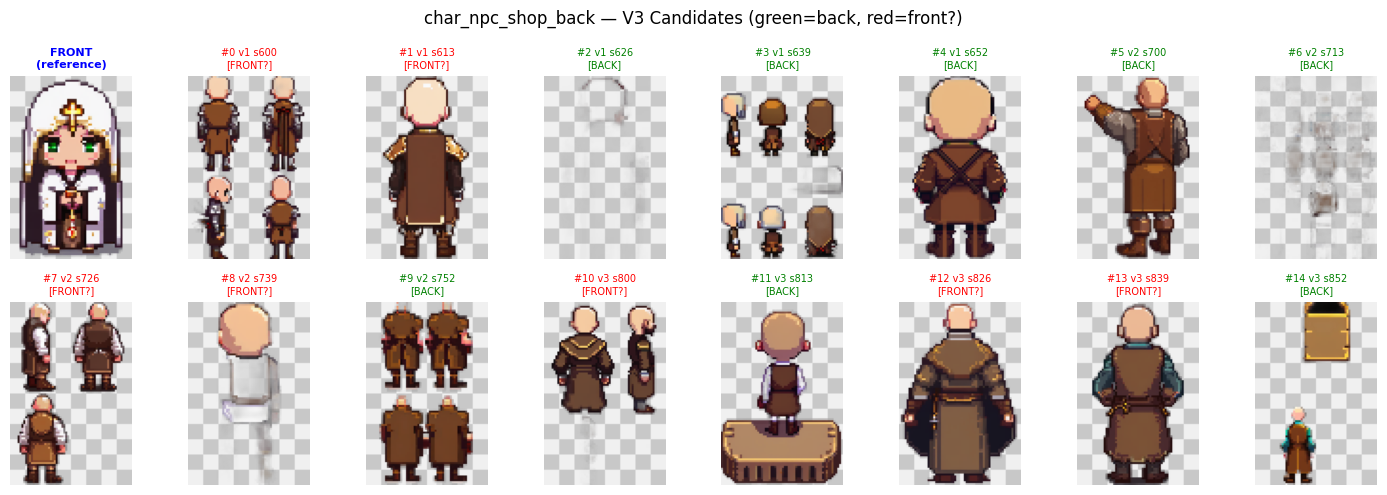

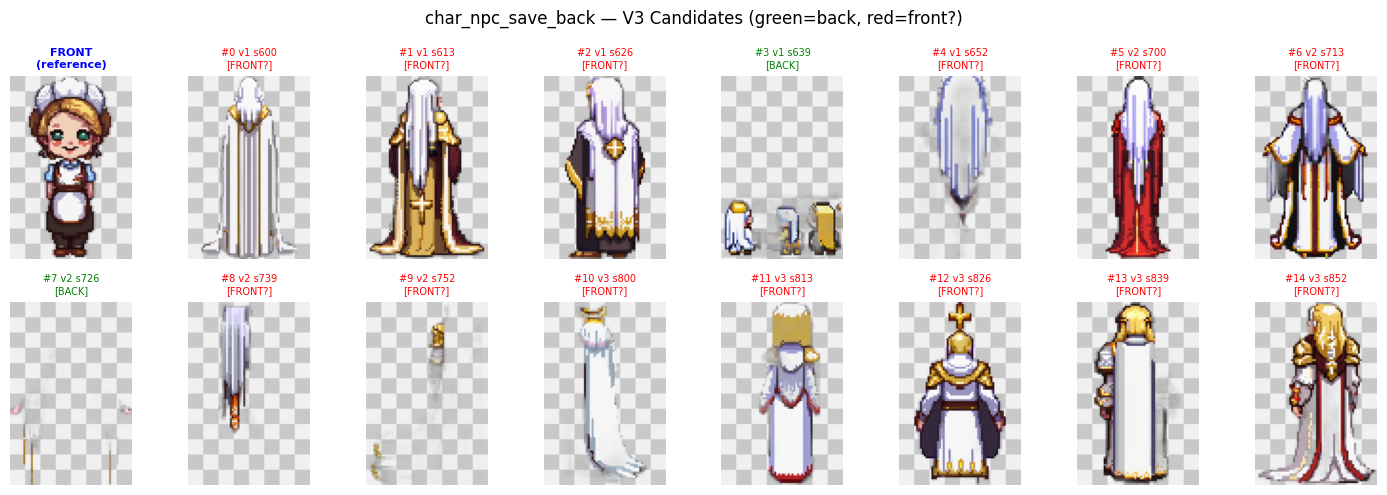


Review the grids above. Set SELECTED below to pick the best back view per NPC.


In [6]:
# Cell 5: Visual review grid — front image + all 15 candidates per NPC
# Green border = detected as back view, Red border = suspected front view

for entry in ENTRIES:
    name = entry['name']
    candidates = all_candidates[name]
    n = len(candidates)
    cols = min(8, n + 1)  # +1 for front reference
    rows = (n + cols) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 2.5))
    axes = np.atleast_2d(axes)
    for ax in axes.flat:
        ax.axis('off')

    # Front reference in top-left
    ax0 = axes[0][0]
    if name in front_images:
        front = front_images[name]
        # Checkerboard bg
        fw, fh = front.size
        checker = np.zeros((fh, fw, 4), dtype=np.uint8)
        for y in range(fh):
            for x in range(fw):
                c = 200 if (x // 8 + y // 8) % 2 == 0 else 240
                checker[y, x] = [c, c, c, 255]
        bg = Image.fromarray(checker, 'RGBA')
        bg.paste(front, (0, 0), front)
        ax0.imshow(bg)
    ax0.set_title('FRONT\n(reference)', fontsize=8, color='blue', fontweight='bold')

    # Candidates
    for i, (vi, seed, proc, raw, is_back) in enumerate(candidates):
        row = (i + 1) // cols
        col = (i + 1) % cols
        ax = axes[row][col]

        pw, ph = proc.size
        checker = np.zeros((ph, pw, 4), dtype=np.uint8)
        for y in range(ph):
            for x in range(pw):
                c = 200 if (x // 8 + y // 8) % 2 == 0 else 240
                checker[y, x] = [c, c, c, 255]
        bg = Image.fromarray(checker, 'RGBA')
        bg.paste(proc, (0, 0), proc)
        ax.imshow(bg)

        color = 'green' if is_back else 'red'
        label = 'BACK' if is_back else 'FRONT?'
        ax.set_title(f'#{i} v{vi+1} s{seed}\n[{label}]', fontsize=7, color=color)

    plt.suptitle(f'{name}_back — V3 Candidates (green=back, red=front?)', fontsize=12)
    plt.tight_layout()
    plt.show()

print('\nReview the grids above. Set SELECTED below to pick the best back view per NPC.')

In [7]:
# Cell 6: Manual selection — pick best candidate index per NPC
# Look at the grid above and enter the # index of the best back view

SELECTED = {
    'char_npc_shop': 0,   # ← Change to best candidate # from grid
    'char_npc_save': 0,   # ← Change to best candidate # from grid
}

# Save selected candidates
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

for name, idx in SELECTED.items():
    candidates = all_candidates[name]
    if idx >= len(candidates):
        print(f'[ERROR] {name}: index {idx} out of range (max {len(candidates)-1})')
        continue
    vi, seed, proc, raw, is_back = candidates[idx]
    out_path = out_dir / f'{name}_back.png'
    proc.save(str(out_path), 'PNG')
    kb = out_path.stat().st_size / 1024
    status = 'BACK' if is_back else 'FRONT?'
    print(f'Saved: {name}_back.png — variant {vi+1}, seed {seed}, [{status}], {kb:.0f}KB')

print('\nDone! Check the saved images above.')

Saved: char_npc_shop_back.png — variant 1, seed 600, [FRONT?], 9KB
Saved: char_npc_save_back.png — variant 1, seed 600, [FRONT?], 5KB

Done! Check the saved images above.


In [8]:
# Cell 7: Export zip
import shutil

d = OUTPUT_BASE / 'overworld_characters'
if d.exists():
    back_files = sorted(d.glob('*_back.png'))
    print(f'Back images to export: {len(back_files)}')
    for f in back_files:
        print(f'  {f.name} ({f.stat().st_size/1024:.0f}KB)')

zip_path = '/content/owc_back_v3_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
zip_size = os.path.getsize(zip_path + '.zip') / 1024 / 1024
print(f'\nZip: {zip_size:.1f} MB -> {zip_path}.zip')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Back images to export: 14
  char_beast_back.png (8KB)
  char_dwarf_back.png (7KB)
  char_elf_back.png (9KB)
  char_giant_back.png (9KB)
  char_guard_back.png (8KB)
  char_hero_back.png (8KB)
  char_merfolk_back.png (8KB)
  char_npc_info_back.png (11KB)
  char_npc_inn_back.png (8KB)
  char_npc_quest_back.png (10KB)
  char_npc_save_back.png (5KB)
  char_npc_shop_back.png (9KB)
  char_treant_back.png (10KB)
  char_undead_back.png (8KB)

Zip: 8.2 MB -> /content/owc_back_v3_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>